# GEE Tile Visualizer

Explore and verify candidate tiles **before** committing to a full export.

## Workflow
1. Set `REGION` in the Config cell below.
2. Run all cells — tile stats print automatically.
3. Inspect the interactive map:
   - **Blue outlines** — all tiles passing quality filters
   - **Green fill** — the tiles that would actually be downloaded (after shuffle + limit)
4. If the tile distribution looks wrong, adjust thresholds in `../config/regions.yaml`.
5. Once satisfied, run the real export:
   ```bash
   # Dry run (stats only)
   python export_to_gcs.py --region brazil --dry-run

   # Local test (2 tiles)
   python export_to_gcs.py --region brazil --local --limit 2

   # Full GCS export
   python export_to_gcs.py --region brazil --bucket e4e-mangrove-tiles
   ```

In [1]:
# ================================================================
# CONFIG — only cell you need to change
# ================================================================
REGION = 'north_australia'  # florida | brazil | indonesia | madagascar_mozambique | east_india_bangladesh | north_australia

In [2]:
import ee
import geemap
import sys
import os
import random
import matplotlib.pyplot as plt

# Import shared filtering logic — avoids duplicating the pipeline
sys.path.insert(0, os.path.abspath('.'))
from export_to_gcs import load_region_config, build_geometry, build_training_stack, get_candidate_tiles

ee.Authenticate()
ee.Initialize(project='e4e-mangrove')
print('Earth Engine initialized.')

Earth Engine initialized.


In [3]:
cfg = load_region_config(REGION)
print(f"Region: {cfg['display_name']}")
print(f"\nActive thresholds (edit in config/regions.yaml to tune):")
print(f"  min_mangrove_pct  : {cfg['min_mangrove_pct']}%")
print(f"  max_water_pct     : {cfg['max_water_pct']}%")
print(f"  max_tree_pct      : {cfg['max_tree_pct']}%")
print(f"  max_bare_built_pct: {cfg['max_bare_built_pct']}%")
print(f"  min_classes       : {cfg['min_classes']}")

region_geom, bounds = build_geometry(cfg)
training_stack, esa_all_classes = build_training_stack(bounds, cfg)

print(f"\nScanning candidate tiles (takes ~1-2 min for large regions)...")
candidates = get_candidate_tiles(region_geom, bounds, esa_all_classes, cfg)

random.seed(cfg['seed'])
random.shuffle(candidates)
selected = candidates[:cfg['sample_size']]

print(f"\n{'='*50}")
print(f"Tiles passing quality filters : {len(candidates)}")
print(f"Tiles selected for download   : {len(selected)}")
print(f"{'='*50}")

Region: North Australia (Kimberley + Top End + Gulf of Carpentaria)

Active thresholds (edit in config/regions.yaml to tune):
  min_mangrove_pct  : 1.0%
  max_water_pct     : 70.0%
  max_tree_pct      : 70.0%
  max_bare_built_pct: 50.0%
  min_classes       : 2

Scanning candidate tiles (takes ~1-2 min for large regions)...
  Tiles with mangrove (pre-filter): 535

Tiles passing quality filters : 247
Tiles selected for download   : 100


In [4]:
def _avg(tiles, key):
    return sum(t[key] for t in tiles) / len(tiles) if tiles else 0.0

print(f"Class composition of SELECTED tiles (n={len(selected)}):")
print(f"  Mangrove   : {_avg(selected, 'mangrove_pct'):.1f}%")
print(f"  Water      : {_avg(selected, 'water_pct'):.1f}%")
print(f"  Tree cover : {_avg(selected, 'tree_pct'):.1f}%")
print(f"  Bare+Built : {_avg(selected, 'bare_built_pct'):.1f}%")
print(f"  Other      : {100 - _avg(selected, 'mangrove_pct') - _avg(selected, 'water_pct') - _avg(selected, 'tree_pct') - _avg(selected, 'bare_built_pct'):.1f}%")
print(f"  Avg classes/tile: {_avg(selected, 'num_classes'):.1f}")

Class composition of SELECTED tiles (n=100):
  Mangrove   : 6.5%
  Water      : 32.0%
  Tree cover : 29.1%
  Bare+Built : 6.7%
  Other      : 25.7%
  Avg classes/tile: 6.6


In [5]:
# Cap display at 500 tiles so the map renders quickly
MAX_DISPLAY = 500

def tiles_to_fc(tiles):
    return ee.FeatureCollection([
        ee.Feature(ee.Geometry(t['geometry']), {
            'mangrove_pct' : t['mangrove_pct'],
            'water_pct'    : t['water_pct'],
            'tree_pct'     : t['tree_pct'],
            'num_classes'  : t['num_classes'],
        })
        for t in tiles[:MAX_DISPLAY]
    ])

fc_candidates = tiles_to_fc(candidates)
fc_selected   = tiles_to_fc(selected)

# ESA mangrove mask (class 95 only)
esa = ee.ImageCollection('ESA/WorldCover/v200').first()
mangrove_mask = esa.eq(95).selfMask()

# Sentinel-2 true color composite
date_start, date_end = cfg['date_range']
s2_rgb = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(bounds)
    .filterDate(date_start, date_end)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', cfg['cloud_pct_max']))
    .median()
    .select(['B4', 'B3', 'B2'])
)

Map = geemap.Map()
Map.centerObject(region_geom, zoom=6)

Map.addLayer(s2_rgb,        {'min': 0, 'max': 3000, 'gamma': 1.4}, 'Sentinel-2 RGB', True)
Map.addLayer(mangrove_mask, {'palette': ['00b300']},                'ESA Mangroves (class 95)', True, 0.7)
Map.addLayer(fc_candidates, {'color': '4488FF'},                    'All passing tiles', True, 0.5)
Map.addLayer(fc_selected,   {'color': '00CC44'},                    f'Selected tiles (n={len(selected)})', True)

# Click any tile on the map to inspect its properties
Map

Map(center=[-15.275319549315062, 133.99999999999997], controls=(WidgetControl(options=['position', 'transparen…

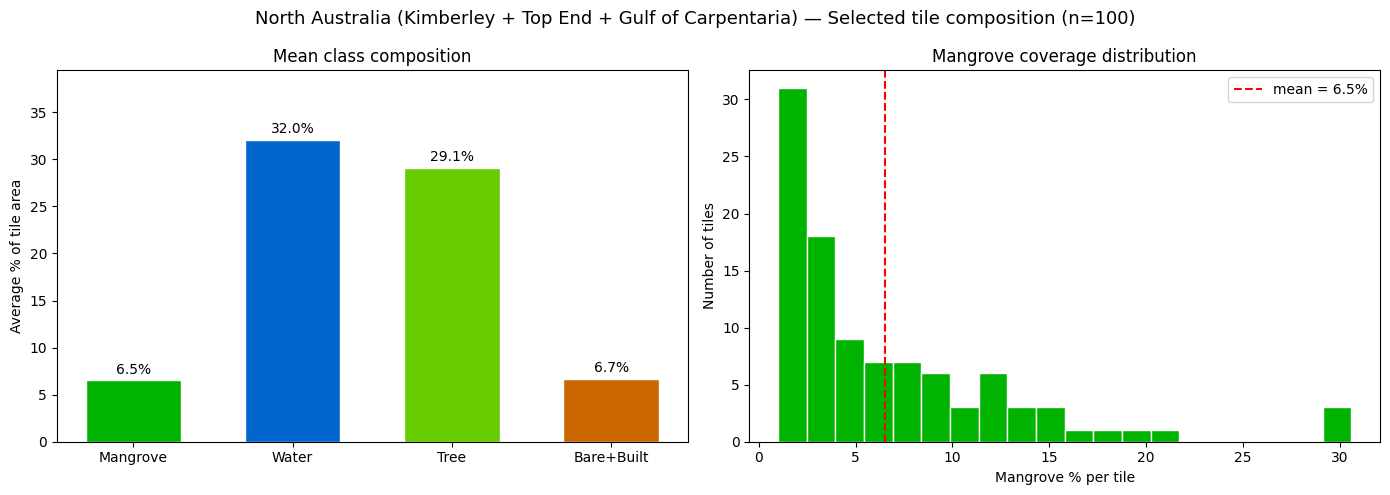

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"{cfg['display_name']} — Selected tile composition (n={len(selected)})",
    fontsize=13
)

# Left: average class composition
labels = ['Mangrove', 'Water', 'Tree', 'Bare+Built']
avgs   = [
    _avg(selected, 'mangrove_pct'),
    _avg(selected, 'water_pct'),
    _avg(selected, 'tree_pct'),
    _avg(selected, 'bare_built_pct'),
]
colors = ['#00b300', '#0066cc', '#66cc00', '#cc6600']

ax = axes[0]
bars = ax.bar(labels, avgs, color=colors, edgecolor='white', width=0.6)
ax.set_ylabel('Average % of tile area')
ax.set_title('Mean class composition')
ax.set_ylim(0, max(avgs) * 1.2 + 1)
for bar, val in zip(bars, avgs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f'{val:.1f}%', ha='center', va='bottom', fontsize=10
    )

# Right: histogram of mangrove % distribution across selected tiles
ax2 = axes[1]
mangrove_vals = [t['mangrove_pct'] for t in selected]
ax2.hist(mangrove_vals, bins=20, color='#00b300', edgecolor='white')
ax2.set_xlabel('Mangrove % per tile')
ax2.set_ylabel('Number of tiles')
ax2.set_title('Mangrove coverage distribution')
mean_val = _avg(selected, 'mangrove_pct')
ax2.axvline(mean_val, color='red', linestyle='--', label=f'mean = {mean_val:.1f}%')
ax2.legend()

plt.tight_layout()
plt.show()

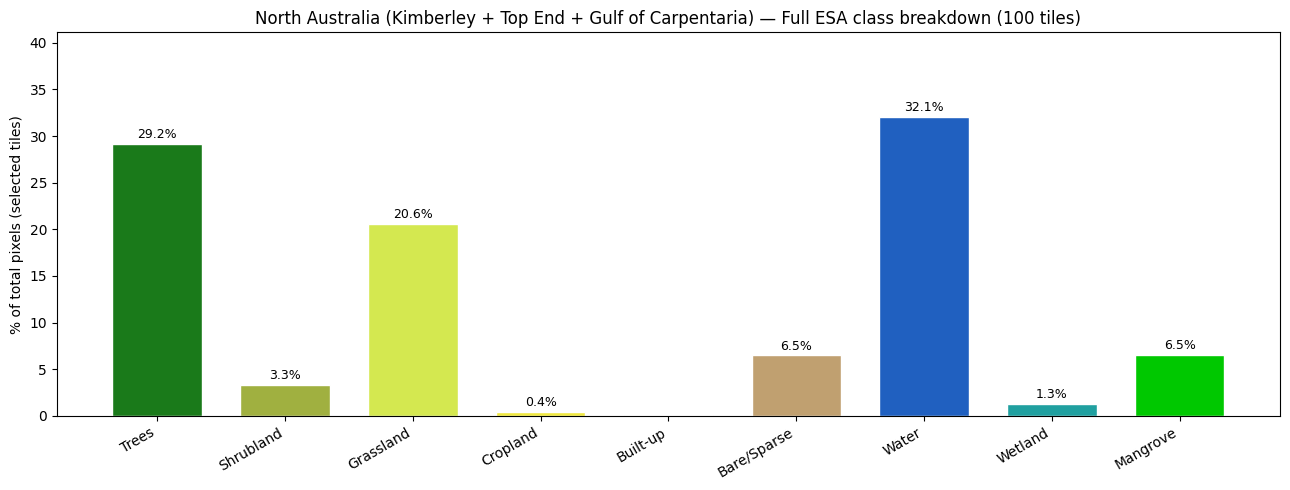

Full ESA class breakdown (descending):
  Water           (ESA  80):  32.1%
  Trees           (ESA  10):  29.2%
  Grassland       (ESA  30):  20.6%
  Mangrove        (ESA  95):   6.5%
  Bare/Sparse     (ESA  60):   6.5%
  Shrubland       (ESA  20):   3.3%
  Wetland         (ESA  90):   1.3%
  Cropland        (ESA  40):   0.4%
  Built-up        (ESA  50):   0.1%


In [7]:
ESA_CLASS_NAMES = {
    10: 'Trees',      20: 'Shrubland',  30: 'Grassland', 40: 'Cropland',
    50: 'Built-up',   60: 'Bare/Sparse', 70: 'Snow/Ice',  80: 'Water',
    90: 'Wetland',    95: 'Mangrove',   100: 'Moss/Lichen',
}
ESA_COLORS = {
    10: '#1a7a1a', 20: '#a0b040', 30: '#d4e850', 40: '#f0e840',
    50: '#c03010', 60: '#c0a070', 70: '#e8f0f8', 80: '#2060c0',
    90: '#20a0a0', 95: '#00c800', 100: '#808060',
}

# Aggregate raw pixel counts across all selected tiles
total_counts: dict[int, int] = {}
for tile in selected:
    for cls, count in tile['hist'].items():
        total_counts[cls] = total_counts.get(cls, 0) + count

grand_total = sum(total_counts.values())
classes_present = sorted(total_counts.keys())
labels = [ESA_CLASS_NAMES.get(c, f'ESA {c}') for c in classes_present]
pcts   = [total_counts[c] / grand_total * 100 for c in classes_present]
colors = [ESA_COLORS.get(c, '#888888') for c in classes_present]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(labels, pcts, color=colors, edgecolor='white', width=0.7)
ax.set_ylabel('% of total pixels (selected tiles)')
ax.set_title(
    f"{cfg['display_name']} — Full ESA class breakdown ({len(selected)} tiles)",
    fontsize=12,
)
ax.set_ylim(0, max(pcts) * 1.25 + 1)
plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, pcts):
    if val > 0.3:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9,
        )
plt.tight_layout()
plt.show()

print('Full ESA class breakdown (descending):')
for cls, pct in sorted(zip(classes_present, pcts), key=lambda x: -x[1]):
    print(f"  {ESA_CLASS_NAMES.get(cls, f'ESA {cls}'):15s} (ESA {cls:3d}): {pct:5.1f}%")

[1/6] Scanning florida...   Tiles with mangrove (pre-filter): 436
done (1s)
[2/6] Scanning brazil...   Tiles with mangrove (pre-filter): 385
done (2s)
[3/6] Scanning indonesia...   Tiles with mangrove (pre-filter): 1000 [WARNING: hit cap, some tiles excluded]
done (1s)
[4/6] Scanning madagascar_mozambique...   Tiles with mangrove (pre-filter): 290
done (5s)
[5/6] Scanning north_australia...   Tiles with mangrove (pre-filter): 535
done (0s)
[6/6] Scanning east_india_bangladesh...   Tiles with mangrove (pre-filter): 141
done (0s)


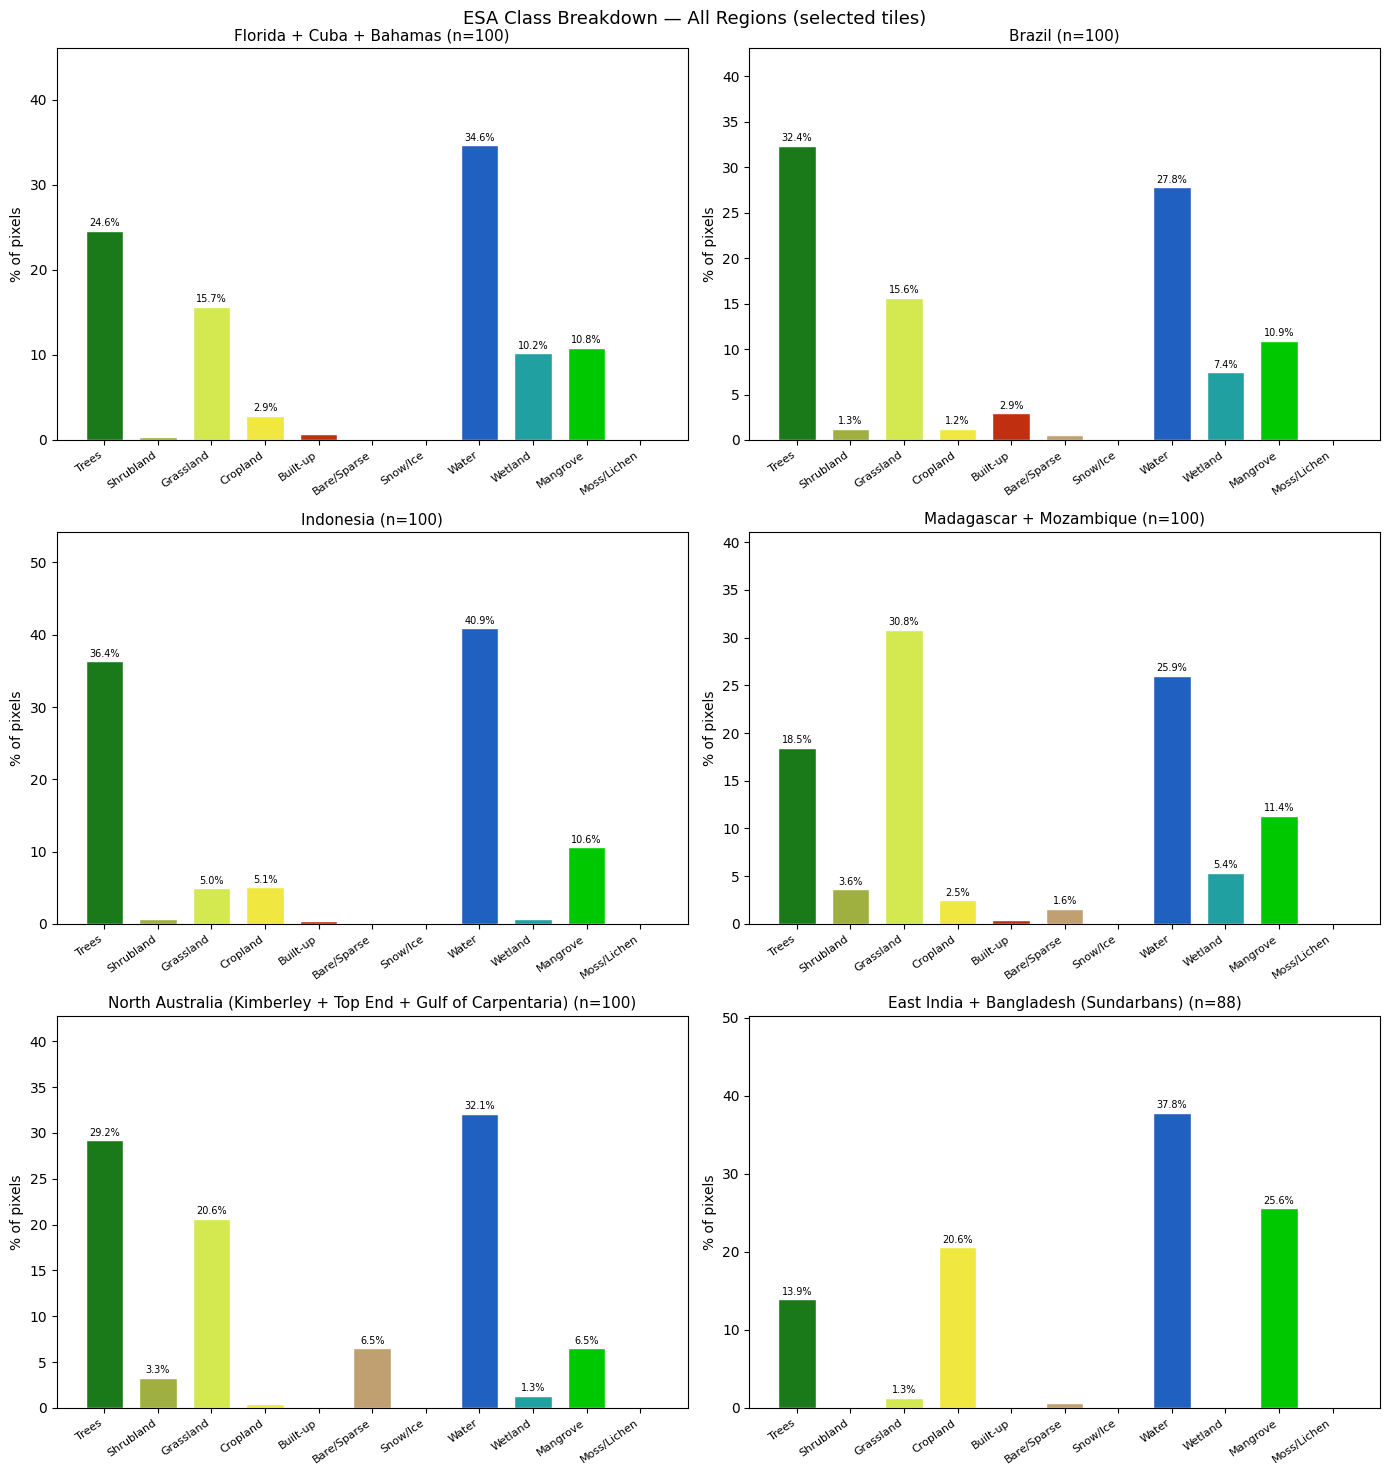


Class               florida      brazil   indonesia  madagascar  north_aust  east_india
---------------------------------------------------------------------------------------
Trees               24.6%      32.4%      36.4%      18.5%      29.2%      13.9% 
Shrubland            0.4%       1.3%       0.7%       3.6%       3.3%       0.0% 
Grassland           15.7%      15.6%       5.0%      30.8%      20.6%       1.3% 
Cropland             2.9%       1.2%       5.1%       2.5%       0.4%      20.6% 
Built-up             0.7%       2.9%       0.4%       0.4%       0.1%       0.1% 
Bare/Sparse          0.1%       0.5%       0.2%       1.6%       6.5%       0.6% 
Water               34.6%      27.8%      40.9%      25.9%      32.1%      37.8% 
Wetland             10.2%       7.4%       0.7%       5.4%       1.3%       0.0% 
Mangrove            10.8%      10.9%      10.6%      11.4%       6.5%      25.6% 


In [8]:
# ── All-regions ESA breakdown ─────────────────────────────────────────────────
# Scans every region in regions.yaml and plots the full ESA class distribution
# side-by-side. Takes ~2 min per region — run once when deciding the global
# class taxonomy for continual learning.

import time, yaml

_CONFIG_PATH = os.path.join(os.path.dirname(os.path.abspath('export_to_gcs.py')), '..', 'config', 'regions.yaml')
with open(_CONFIG_PATH) as _f:
    ALL_REGION_KEYS = list(yaml.safe_load(_f).keys())

_ESA_CLASS_NAMES = {
    10: 'Trees',     20: 'Shrubland', 30: 'Grassland',  40: 'Cropland',
    50: 'Built-up',  60: 'Bare/Sparse', 70: 'Snow/Ice', 80: 'Water',
    90: 'Wetland',   95: 'Mangrove',  100: 'Moss/Lichen',
}
_ESA_COLORS = {
    10: '#1a7a1a', 20: '#a0b040', 30: '#d4e850', 40: '#f0e840',
    50: '#c03010', 60: '#c0a070', 70: '#e8f0f8', 80: '#2060c0',
    90: '#20a0a0', 95: '#00c800', 100: '#808060',
}
_ALL_ESA = [10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 100]

_n  = len(ALL_REGION_KEYS)
_nc = 2
_nr = (_n + 1) // _nc
fig_all, axes_all = plt.subplots(_nr, _nc, figsize=(14, 5 * _nr))
axes_all = axes_all.flatten()

_region_pcts = {}   # store for cross-region comparison print at end

for _i, _rname in enumerate(ALL_REGION_KEYS):
    _ax = axes_all[_i]
    _t0 = time.time()
    print(f'[{_i+1}/{_n}] Scanning {_rname}...', end=' ', flush=True)
    try:
        _rc  = load_region_config(_rname)
        _rg, _rb = build_geometry(_rc)
        _, _re   = build_training_stack(_rb, _rc)
        _cands   = get_candidate_tiles(_rg, _rb, _re, _rc)

        random.seed(_rc['seed'])
        random.shuffle(_cands)
        _sel = _cands[:_rc['sample_size']]

        _counts = {}
        for _tile in _sel:
            for _cls, _cnt in _tile['hist'].items():
                _counts[_cls] = _counts.get(_cls, 0) + _cnt

        _tot  = sum(_counts.values()) or 1
        _pcts = [_counts.get(c, 0) / _tot * 100 for c in _ALL_ESA]
        _region_pcts[_rname] = dict(zip(_ALL_ESA, _pcts))

        _bars = _ax.bar(
            [_ESA_CLASS_NAMES[c] for c in _ALL_ESA], _pcts,
            color=[_ESA_COLORS[c] for c in _ALL_ESA],
            edgecolor='white', width=0.7,
        )
        _ax.set_title(f"{_rc['display_name']} (n={len(_sel)})", fontsize=11)
        _ax.set_ylabel('% of pixels')
        _ax.set_ylim(0, max(_pcts) * 1.3 + 1)
        plt.setp(_ax.get_xticklabels(), rotation=35, ha='right', fontsize=8)
        for _bar, _val in zip(_bars, _pcts):
            if _val > 1.0:
                _ax.text(
                    _bar.get_x() + _bar.get_width() / 2,
                    _bar.get_height() + 0.3,
                    f'{_val:.1f}%', ha='center', va='bottom', fontsize=7,
                )
        print(f'done ({time.time()-_t0:.0f}s)')
    except Exception as _e:
        _ax.set_title(f'{_rname} — ERROR')
        _ax.text(0.5, 0.5, str(_e), ha='center', va='center',
                 transform=_ax.transAxes, fontsize=8, wrap=True)
        print(f'ERROR: {_e}')

for _i in range(_n, len(axes_all)):
    axes_all[_i].set_visible(False)

fig_all.suptitle('ESA Class Breakdown — All Regions (selected tiles)', fontsize=13)
plt.tight_layout()
plt.show()

# Cross-region summary table — which classes appear in multiple regions
print(f'\n{"Class":<15}', end='')
for _rk in ALL_REGION_KEYS:
    print(f'  {_rk[:10]:>10}', end='')
print()
print('-' * (15 + 12 * _n))
for _cls in _ALL_ESA:
    _name = _ESA_CLASS_NAMES[_cls]
    _row  = [_region_pcts.get(_rk, {}).get(_cls, 0.0) for _rk in ALL_REGION_KEYS]
    _max  = max(_row)
    if _max < 0.5:
        continue   # skip globally absent classes
    print(f'{_name:<15}', end='')
    for _v in _row:
        _flag = ' *' if _v > 5.0 else ('  ' if _v > 0.5 else '  -')
        print(f'  {_v:>7.1f}%{_flag[0]}', end='')
    print()